# Library

In [25]:
import sys
sys.path.append("/project/assistant")

%load_ext autoreload
%autoreload 2

import os

# huggingface downloads: quiet text logs, no widget progress bars
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_VERBOSITY"] = "error"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from elasticsearch import Elasticsearch

from embeddings import SentenceTransformerEmbeddings
from search import VaultSearcher, ElasticsearchRetriever

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Search

In [26]:
model_name = os.getenv("EMBED_MODEL", "all-MiniLM-L6-v2")
query_prefix = ("Represent this sentence for searching relevant passages: "
                if "bge" in model_name else "")

es = Elasticsearch(os.getenv("ELASTIC_HOST", "http://elasticsearch:9200"))
embeddings = SentenceTransformerEmbeddings(model_name, query_prefix)
searcher = VaultSearcher(es, embeddings, os.getenv("ES_INDEX", "obsidian_notes"))
retriever = ElasticsearchRetriever(search_fn=searcher.hybrid, num_results=10)

In [27]:
def compare(question, num_results=3):
    """The three searches side by side for one question."""
    print(f"Q: {question}\n")
    for name, fn in [("TEXT  ", searcher.text),
                     ("VECTOR", searcher.vector),
                     ("HYBRID", searcher.hybrid)]:
        print(f"{name}:")
        for doc in fn(question, num_results=num_results):
            print(f"  {doc['_score']:8.4f}  {doc['path']}::{doc['start']}")
        print()


compare("Is it necessary to use Docker to install sqlite?")

Q: Is it necessary to use Docker to install sqlite?

TEXT  :
    9.9183  llm-zoomcamp-2026/02-vector-search/01-intro-vector-search.md::2000
    9.7924  llm-zoomcamp-2026/01-agentic-rag/09-data-ingestion.md::1000
    9.5602  llm-zoomcamp-2026/01-agentic-rag/09-data-ingestion.md::0

VECTOR:
    0.7071  llm-zoomcamp-2026/05-monitoring/07-streamlit-dashboard.md::0
    0.6858  project/02-architecture.md::0
    0.6768  concepts/monitoring.md::19000

HYBRID:
    0.0164  llm-zoomcamp-2026/02-vector-search/01-intro-vector-search.md::2000
    0.0164  llm-zoomcamp-2026/05-monitoring/07-streamlit-dashboard.md::0
    0.0161  llm-zoomcamp-2026/01-agentic-rag/09-data-ingestion.md::1000



# Search Evaluation

Retrieval is evaluated against a synthetic ground-truth dataset of 200 question–note pairs, generated by an LLM after reading every note in the vault. The dataset contains 50 easy questions, which ask directly about note content, and 150 hard questions, written as adversarial paraphrases that deliberately use vocabulary different from the target note.

The hard subset is the main benchmark for distinguishing retrieval methods, since performance on the easy questions is already close to saturation. The complete dataset is committed at `data/claude_ground_truth.json`, making all results below reproducible.

Evaluation uses the two retrieval metrics adopted in the course: **Hit Rate@10**, which checks whether the expected note appears anywhere in the top 10 results, regardless of which chunk retrieves it, and **MRR**, which measures how early the correct note appears in the ranking, assigning a score of 1 to rank 1, 1/2 to rank 2, ..., and 1/10 to rank 10.


In [28]:
seed = pd.read_json("/project/data/claude_ground_truth.json")
print(len(seed), "questions |", dict(seed.difficulty.value_counts()))
seed.sample(5, random_state=1)

200 questions | {'hard': np.int64(150), 'easy': np.int64(50)}


,question,path,difficulty
58,do i still need to end my message with a hint ...,llm-zoomcamp-2026/01-agentic-rag/03-rag.md,hard
40,why do the timestamps in the database need to ...,llm-zoomcamp-2026/05-monitoring/05-database.md,easy
34,can I use another llm to check if my judge is ...,llm-zoomcamp-2026/04-evaluation/13-llm-as-judg...,easy
102,once texts are turned into lists of numbers ho...,llm-zoomcamp-2026/02-vector-search/02-embeddin...,hard
184,once real traffic shows up do we really have t...,llm-zoomcamp-2026/05-monitoring/09-built-in-ju...,hard


Each note was read in full and contributed its own set of question-note pairs. Easy questions stay close to the note's original wording, while hard questions ask about the same content using deliberately different vocabulary.

The dataset was generated with Claude agents from Claude Code using Flable 5 model during development and then committed as a fixed evaluation artifact. The benchmark therefore depends only on the saved dataset, not on regenerating questions at evaluation time.

In [29]:
print("Easy questions:")
display(list(seed[seed['difficulty'] == 'easy']['question'][:10]))

print("\n Hard questions:")
display(list(seed[seed['difficulty'] == 'hard']['question'][:10]))

Easy questions:


['why cant a plain llm answer questions about my own documents',
 'where should I put my openai api key so it does not end up on github',
 'what are the main components of a rag pipeline',
 'what information does each entry in the faq dataset contain',
 'what is the difference between text fields and keyword fields in the search index',
 'why do we keep the instructions separate from the user prompt',
 'why does the course use the responses api instead of chat completions',
 'why put the rag code into a class instead of plain functions',
 'how do I make the search index survive a restart without reindexing everything',
 'should I fine tune the model on my data or just use rag']


 Hard questions:


['why do we code the whole thing ourselves first instead of grabbing a ready made toolkit',
 'my phone guesses the next word when i type, is that basically what these big models are doing',
 'what goes wrong if i ask the model about stuff that happened after it finished learning',
 'why do they push the cloud coding setup from github instead of everyone working on their own laptop',
 'how can i see what just this course is costing me apart from my other ai spending',
 'whats the least amount of money i have to load up before i can even make a call',
 'why can the bot explain how to cook fish perfectly but knows nothing about our classes',
 'if i want to switch to a different ai company what parts of my code actually change',
 'do i still need to end my message with a hint word so the model completes the sentence like in the old days',
 'the data here comes ready to use, what messy work does that hide in a real project']

The evaluation runs against a dedicated index containing only the course notes, the corpus the ground truth targets. It is rebuilt here in seconds from the repo's demo copy, so the measurement reproduces identically whatever vault the app is serving, and the app's index is untouched. Someone evaluating their own vault with their own ground truth would point the searcher at the app index (`obsidian_notes`) instead.

In [30]:
# side index from the course corpus only (the ground truth's target),
# with source and folder matching the original vault layout, so the
# numbers align with the known baseline
EVAL_INDEX = "rewrite_eval"

from cleaner import NoteCleaner
from ingest import VaultLoader, SlidingWindowSplitter, ElasticsearchIndexer

docs = VaultLoader("/project/demo_vault/llm-zoomcamp-2026", NoteCleaner()).load()
for d in docs:
    d.metadata["source"] = "llm-zoomcamp-2026/" + d.metadata["source"]
    d.metadata["folder"] = "llm-zoomcamp-2026/" + d.metadata["folder"]
chunks = SlidingWindowSplitter(chunk_size=2000, chunk_overlap=1000).split_documents(docs)
print(f"{len(docs)} notes -> {len(chunks)} chunks")

indexer = ElasticsearchIndexer(es, embeddings, index=EVAL_INDEX, add_context_header=True)
indexer.create_index(recreate=True)
indexer.index_documents(chunks)
es.indices.refresh(index=EVAL_INDEX)

searcher = VaultSearcher(es, embeddings, EVAL_INDEX)

51 notes -> 218 chunks


In [31]:
def evaluate_search(search_fn, questions, num_results=10, folder=None):
    """Hit rate and mrr at top num_results: hit when the expected note
    appears among the results (any chunk of it), mrr rewarding it for
    appearing early."""
    hits, rr = 0, 0.0
    for q in tqdm(questions.itertuples(), total=len(questions)):
        paths = [r["path"] for r in search_fn(q.question, num_results=num_results, folder=folder)]
        if q.path in paths:
            hits += 1
            rr += 1 / (paths.index(q.path) + 1)
    n = len(questions)
    return {"hit_rate": hits / n, "mrr": rr / n}


scores = {name: evaluate_search(fn, seed)
          for name, fn in [("text", searcher.text),
                           ("vector", searcher.vector),
                           ("hybrid", searcher.hybrid)]}
pd.DataFrame(scores).T

100%|██████████| 200/200 [00:07<00:00, 26.36it/s]


,hit_rate,mrr
text,0.680,0.463173
vector,0.715,0.454617
hybrid,0.755,0.491440


- **Hit Rate@10** measures presence: did the expected note appear anywhere among the top 10 results?
- **MRR** measures rank: how early did the expected note appear, assigning a score of 1 at rank 1, 1/2 at rank 2, ..., and 1/10 at rank 10.

100%|██████████| 150/150 [00:04<00:00, 34.14it/s]


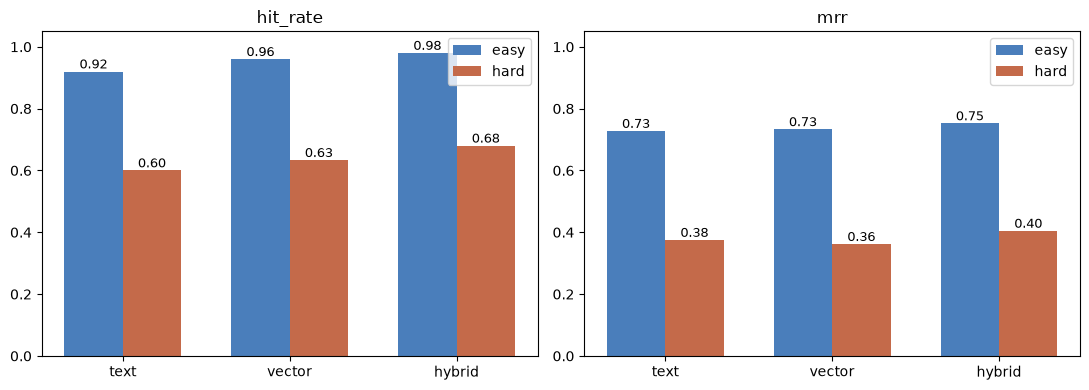

In [32]:
methods = ["text", "vector", "hybrid"]
fns = {"text": searcher.text, "vector": searcher.vector, "hybrid": searcher.hybrid}
by = {m: {d: evaluate_search(fns[m], seed[seed.difficulty == d])
          for d in ("easy", "hard")} for m in methods}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(methods))
w = 0.35

for ax, metric in ((ax1, "hit_rate"), (ax2, "mrr")):
    easy = [by[m]["easy"][metric] for m in methods]
    hard = [by[m]["hard"][metric] for m in methods]
    ax.bar(x - w/2, easy, w, label="easy", color="#4a7ebb")
    ax.bar(x + w/2, hard, w, label="hard", color="#c46a4a")
    for i, v in enumerate(easy):
        ax.text(i - w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    for i, v in enumerate(hard):
        ax.text(i + w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    ax.set_xticks(x, methods)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()

Where do retrieval failures occur? Each row corresponds to one question and records the rank of the expected note together with the note that was retrieved first instead.

The analysis looks at the errors from three angles: misses per note, to detect whether specific notes are systematically difficult to retrieve; confusion pairs, to identify which notes are repeatedly mistaken for one another; and the rank distribution of successful hits, to measure how often the correct note appears late in the result list, the cases where reranking helps most.


In [33]:
def analyze_search(search_fn, questions, num_results=10, folder=None):
    """One row per question: where the expected note landed and what
    took its place. The raw material for every diagnosis below."""
    rows = []
    for q in tqdm(questions.itertuples(), total=len(questions)):
        paths = [r["path"] for r in search_fn(q.question, num_results=num_results, folder=folder)]
        rank = paths.index(q.path) + 1 if q.path in paths else None
        rows.append({"question": q.question, "difficulty": q.difficulty,
                     "expected": q.path, "rank": rank,
                     "hit": rank is not None,
                     "got_top1": paths[0] if paths else None})
    return pd.DataFrame(rows)


results = analyze_search(searcher.hybrid, seed)
misses = results[~results.hit]

print("== hardest notes to find (misses per expected note) ==")
print(misses.groupby("expected").size().sort_values(ascending=False).head(8))
print("\n== confusion pairs: expected -> who stole the top-1 ==")
print(misses.groupby(["expected", "got_top1"]).size()
      .sort_values(ascending=False).head(8))
print("\n== where the hits land (rank distribution) ==")
print(results[results.hit]["rank"].value_counts().sort_index())

100%|██████████| 200/200 [00:05<00:00, 33.50it/s]

== hardest notes to find (misses per expected note) ==
expected
llm-zoomcamp-2026/01-agentic-rag/11-agents-intro.md             3
llm-zoomcamp-2026/01-agentic-rag/10-rag-next-steps.md           3
llm-zoomcamp-2026/01-agentic-rag/12-rag-revision.md             3
llm-zoomcamp-2026/02-vector-search/01-intro-vector-search.md    3
llm-zoomcamp-2026/04-evaluation/04-search-evaluation.md         3
llm-zoomcamp-2026/02-vector-search/05-minsearch-vector.md       2
llm-zoomcamp-2026/01-agentic-rag/15-frameworks.md               2
llm-zoomcamp-2026/04-evaluation/01-intro-evaluation.md          2
dtype: int64

== confusion pairs: expected -> who stole the top-1 ==
expected                                                got_top1                                                    
llm-zoomcamp-2026/01-agentic-rag/10-rag-next-steps.md   llm-zoomcamp-2026/01-agentic-rag/04-dataset.md                  2
llm-zoomcamp-2026/01-agentic-rag/03-rag.md              llm-zoomcamp-2026/01-agentic-rag/16-other-fr

How deep does the result list need to be? Plotting Hit Rate@k shows the value added by each additional retrieved result. Hybrid search performs best at every depth, and its curve is still rising noticeably between $k=5$ and $k=10$.

This supports using 10 retrieved chunks as context for the LLM rather than stopping at 5: the additional depth still recovers a meaningful number of otherwise missed notes.



100%|██████████| 200/200 [00:04<00:00, 41.48it/s]


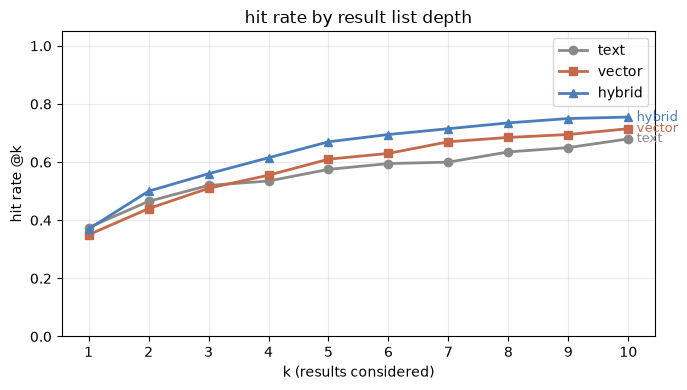

In [34]:
ranks = {"hybrid": results}
for name, fn in [("text", searcher.text), ("vector", searcher.vector)]:
    ranks[name] = analyze_search(fn, seed)

ks = range(1, 11)
styles = {"text": ("#8a8a8a", "o"), "vector": ("#c46a4a", "s"), "hybrid": ("#4a7ebb", "^")}

plt.figure(figsize=(7, 4))
for name in ["text", "vector", "hybrid"]:
    curve = [(ranks[name]["rank"] <= k).mean() for k in ks]
    color, marker = styles[name]
    plt.plot(ks, curve, color=color, marker=marker, linewidth=2,
             markersize=6, label=name)
    plt.annotate(name, (10, curve[-1]), xytext=(6, 0),
                 textcoords="offset points", color=color,
                 fontsize=9, va="center")
plt.xlabel("k (results considered)")
plt.ylabel("hit rate @k")
plt.title("hit rate by result list depth")
plt.xticks(list(ks))
plt.ylim(0, 1.05)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


Among the 200 questions, 151 retrieve the expected note somewhere in the top 10. This chart looks only at those successful cases and shows where the expected note appears in the ranking.

Rank 1 represents perfect retrievals, where the correct note is returned first. Ranks 2 through 10 are late hits: the correct note is found, but appears behind semantically related alternatives.

The pattern is clear: 74 hits arrive at rank 1, while 77 arrive later. In other words, roughly half of the successful retrievals identify the correct note but still place it behind neighboring notes on the same topic.

Hit Rate@10 does not capture this distinction because the LLM receives all 10 chunks either way. MRR does, and the ordering can also affect answer quality because more relevant context appears earlier. This tail of late hits is precisely the failure mode targeted by the reranking stage below.



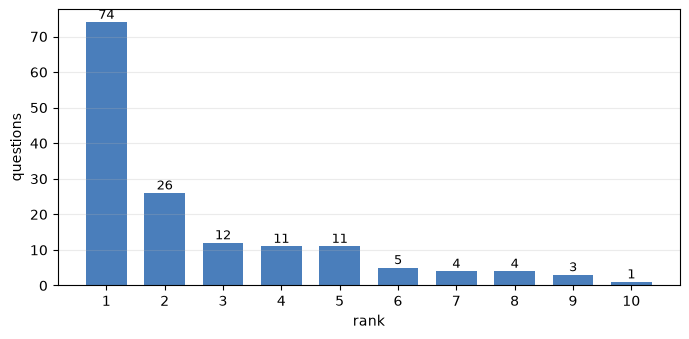

In [35]:
rank_counts = results[results.hit]["rank"].value_counts().sort_index()

plt.figure(figsize=(7, 3.5))
plt.bar(rank_counts.index, rank_counts.values, color="#4a7ebb", width=0.7)
for x, v in rank_counts.items():
    plt.text(x, v + 1, str(int(v)), ha="center", fontsize=9)
plt.xlabel("rank")
plt.ylabel("questions")
# plt.title("where the hits land")
plt.xticks(range(1, 11))
plt.grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()


## **Reranking:** Cross-Encoder

The diagnosis above shows the typical near-miss pattern: roughly half of the successful retrievals place the expected note between ranks 2 and 10, usually behind semantically related notes.

The remedy is a cross-encoder reranker. Hybrid search first retrieves 30 candidates, then the cross-encoder evaluates each query-chunk pair jointly and assigns a new relevance score. The top 10 rescored candidates are kept as the final result.

This second stage provides finer relevance estimates than the bi-encoder used for initial retrieval, at the cost of evaluating every candidate pair at query time.


In [36]:
for h in searcher.rerank("Is it necessary to use Docker to install sqlite?", num_results=3):
    print(f"{h['_score']:8.3f}  {h['path']}::{h['start']}")

  -2.163  llm-zoomcamp-2026/05-monitoring/05-database.md::1000
  -2.396  llm-zoomcamp-2026/02-vector-search/08-pgvector.md::0
  -2.446  llm-zoomcamp-2026/05-monitoring/07-streamlit-dashboard.md::0


In [37]:
# full rerank evaluation over the 200 questions (~13 minutes on cpu)
rerank_results = analyze_search(searcher.rerank, seed)
display(rerank_results.head())

100%|██████████| 200/200 [10:13<00:00,  3.07s/it]


,question,difficulty,expected,rank,hit,got_top1
0,why cant a plain llm answer questions about my...,easy,llm-zoomcamp-2026/01-agentic-rag/01-intro-agen...,5.0,True,llm-zoomcamp-2026/01-agentic-rag/03-rag.md
1,where should I put my openai api key so it doe...,easy,llm-zoomcamp-2026/01-agentic-rag/02-environmen...,1.0,True,llm-zoomcamp-2026/01-agentic-rag/02-environmen...
2,what are the main components of a rag pipeline,easy,llm-zoomcamp-2026/01-agentic-rag/03-rag.md,NaN,False,llm-zoomcamp-2026/05-monitoring/02-assistant-s...
3,what information does each entry in the faq da...,easy,llm-zoomcamp-2026/01-agentic-rag/04-dataset.md,1.0,True,llm-zoomcamp-2026/01-agentic-rag/04-dataset.md
4,what is the difference between text fields and...,easy,llm-zoomcamp-2026/01-agentic-rag/05-search.md,1.0,True,llm-zoomcamp-2026/01-agentic-rag/05-search.md


In [38]:
hit = rerank_results["hit"].mean()
mrr = (1 / rerank_results["rank"]).fillna(0).mean()
print(f"rerank overall: hit {hit:.3f} | mrr {mrr:.3f}")

rerank overall: hit 0.765 | mrr 0.543


- **Hit Rate@10** measures presence: did the expected note appear anywhere among the top 10 results?
- **MRR** measures rank: how early did the expected note appear, assigning a score of 1 at rank 1, 1/2 at rank 2, ..., and 1/10 at rank 10.

On hit rate, hybrid search performs best, reaching 0.98 on the easy subset and 0.68 on the hard subset. Reranking changes this only marginally because it does not retrieve new candidates; it only reorders those already found.

On MRR, the three first-stage search methods remain relatively close, while the reranker clearly separates itself, reaching 0.86 on easy questions and 0.44 on hard ones. This is expected: retrieval determines whether the correct note is found, while reranking determines how high it appears.

The two metrics therefore capture two different capabilities: search finds the right candidate; reranking puts it in the right position.



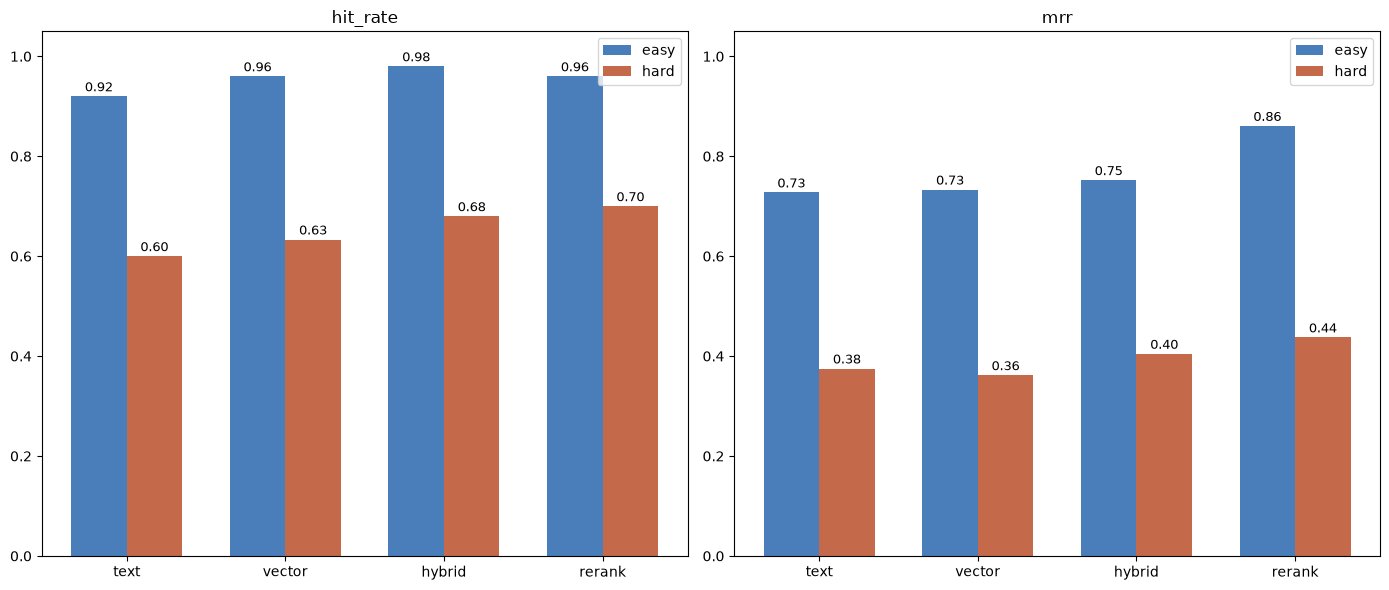

In [39]:
rerank_by = {}
for d in ("easy", "hard"):
    part = rerank_results[rerank_results.difficulty == d]
    rerank_by[d] = {"hit_rate": part["hit"].mean(),
                    "mrr": (1 / part["rank"]).fillna(0).mean()}

methods = ["text", "vector", "hybrid", "rerank"]
full = {**by, "rerank": rerank_by}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x = np.arange(len(methods))
w = 0.35

for ax, metric in ((ax1, "hit_rate"), (ax2, "mrr")):
    easy = [full[m]["easy"][metric] for m in methods]
    hard = [full[m]["hard"][metric] for m in methods]
    ax.bar(x - w/2, easy, w, label="easy", color="#4a7ebb")
    ax.bar(x + w/2, hard, w, label="hard", color="#c46a4a")
    for i, v in enumerate(easy):
        ax.text(i - w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    for i, v in enumerate(hard):
        ax.text(i + w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    ax.set_xticks(x, methods)
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()


## **Query Rewriting:** LLM as Translator

The diagnosis above found two diseases, and the reranker treats only the first. Vocabulary gaps are the second: hard questions whose words share almost nothing with their target note — "the thing doing the lookups" for a note about a search engine. When that happens the correct note never enters the candidate set, and no amount of reordering can recover it.

Query rewriting places an LLM in front of retrieval as a translator: it rewrites the question into the domain's vocabulary before searching. Two designs are measured against the hybrid baseline, plus one combination:

- **replace** searches with the rewritten query only. Maximum translation effect, but a poor rewrite can damage an easy question that already retrieved the correct note.
- **fused** runs hybrid twice, with the original and the rewritten query, and merges the two rankings with reciprocal rank fusion. The original ranking protects what already works; the translation adds candidates the original vocabulary cannot reach.
- **fused_rerank** stacks the cross-encoder on top of the fused candidates: each remedy treating its own disease, in theory.

`QueryRewriter` and `RewriteFusedSearch` below come from the package (`rewriter.py`), the exact code the application runs. The translator works at temperature zero and falls back to the original question on any failure, so it can be absent, never in the way.

In [40]:
from openai import OpenAI

from rewriter import QueryRewriter, RewriteFusedSearch

rewriter = QueryRewriter(OpenAI(), model="gpt-5.4-mini")
fused = RewriteFusedSearch(searcher, rewriter)

# rescued cases straight from the measurement: hard questions that plain
# hybrid missed and fused recovered, with the translation re-run live
rw_results = pd.read_csv("/project/data/query_rewriting_eval.csv")
hyb = rw_results[rw_results.config == "hybrid"].set_index("question")
fus = rw_results[rw_results.config == "fused"].set_index("question")
rescued = fus[(~hyb.hit) & fus.hit & (fus.difficulty == "hard")]

for question, row in rescued.head(3).iterrows():
    print("question: ", question)
    print("rewritten:", rewriter.rewrite(question))
    print("expected: ", row.expected)
    print(f"rank:      miss with hybrid -> {int(row['rank'])} with fused")
    print("-" * 72)

question:  why does sloppy wording in the template let the model drift off and invent stuff
rewritten: prompt template wording ambiguity model drift hallucination generation errors instruction following prompt engineering
expected:  llm-zoomcamp-2026/01-agentic-rag/06-building-prompt.md
rank:      miss with hybrid -> 3 with fused
------------------------------------------------------------------------
question:  why do i have to send the entire back and forth again on every single call
rewritten: conversation history context window prompt tokens chat state stateless API repeated messages full transcript every call chat memory conversation replay context preservation
expected:  llm-zoomcamp-2026/01-agentic-rag/07-llm.md
rank:      miss with hybrid -> 7 with fused
------------------------------------------------------------------------
question:  is there a shortcut to grab the reply text without digging through nested objects
rewritten: extract reply text from nested response objects sh

The full measurement: all 200 ground truth questions through the four configs, produced by the exploration notebook `09082026_query_rewriting_evaluation.ipynb` (about 30 minutes, dominated by the per-question rewrite calls and the cross-encoder) and cached at `data/query_rewriting_eval.csv`. The examples above are read from that cache; the table below summarizes it.

In [41]:
def rw_metrics(frame):
    """Hit rate and mrr, overall and split by difficulty."""
    return pd.Series({
        "hit_rate": frame["hit"].mean(),
        "mrr": (1 / frame["rank"]).fillna(0).mean(),
        "easy_hit": frame[frame.difficulty == "easy"]["hit"].mean(),
        "hard_hit": frame[frame.difficulty == "hard"]["hit"].mean(),
        "easy_mrr": (1 / frame[frame.difficulty == "easy"]["rank"]).fillna(0).mean(),
        "hard_mrr": (1 / frame[frame.difficulty == "hard"]["rank"]).fillna(0).mean(),
    })


rw_configs = ["hybrid", "replace", "fused", "fused_rerank"]
rw_frames = {c: rw_results[rw_results.config == c] for c in rw_configs}
pd.DataFrame({c: rw_metrics(rw_frames[c]) for c in rw_configs}).T.round(3)

,hit_rate,mrr,easy_hit,hard_hit,easy_mrr,hard_mrr
hybrid,0.755,0.491,0.98,0.680,0.752,0.405
replace,0.815,0.571,0.88,0.793,0.712,0.523
fused,0.885,0.577,0.96,0.860,0.801,0.502
fused_rerank,0.810,0.556,0.96,0.760,0.861,0.454


Hit rate and MRR per config, split by difficulty. The easy bars answer the first question about any rewriting scheme — does it break what already works? — and the hard bars measure what it was hired for.

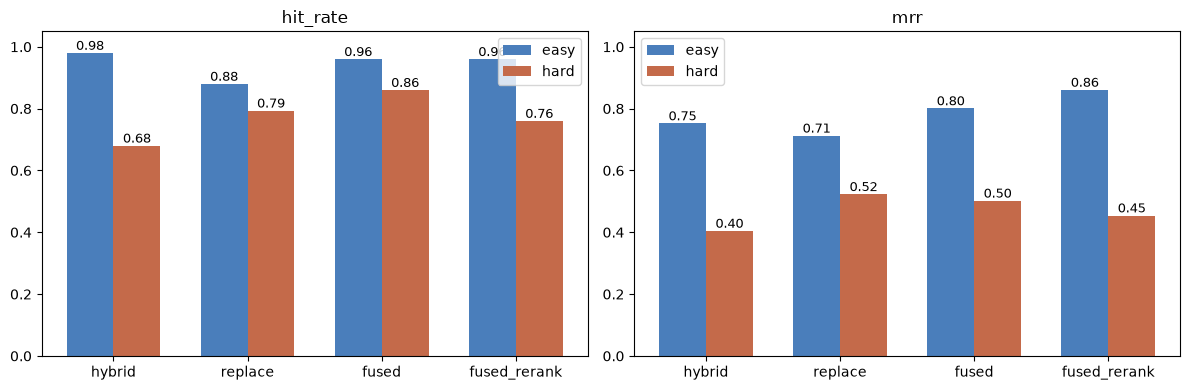

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(rw_configs))
w = 0.35
for ax, suffix, title in ((ax1, "_hit", "hit_rate"), (ax2, "_mrr", "mrr")):
    easy = [rw_metrics(rw_frames[c])["easy" + suffix] for c in rw_configs]
    hard = [rw_metrics(rw_frames[c])["hard" + suffix] for c in rw_configs]
    ax.bar(x - w/2, easy, w, label="easy", color="#4a7ebb")
    ax.bar(x + w/2, hard, w, label="hard", color="#c46a4a")
    for i, v in enumerate(easy):
        ax.text(i - w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    for i, v in enumerate(hard):
        ax.text(i + w/2, v + 0.01, f"{v:.2f}", ha="center", fontsize=9)
    ax.set_xticks(x, rw_configs)
    ax.set_title(title)
    ax.set_ylim(0, 1.05)
    ax.legend()
plt.tight_layout()
plt.show()

The same data as one picture: each curve is the share of questions whose expected note appears at rank k or better, so the gap between the end of a curve and 1.0 is its miss rate. Fused dominates at every depth; replace trades easy losses for hard gains; fused_rerank sits below fused everywhere.

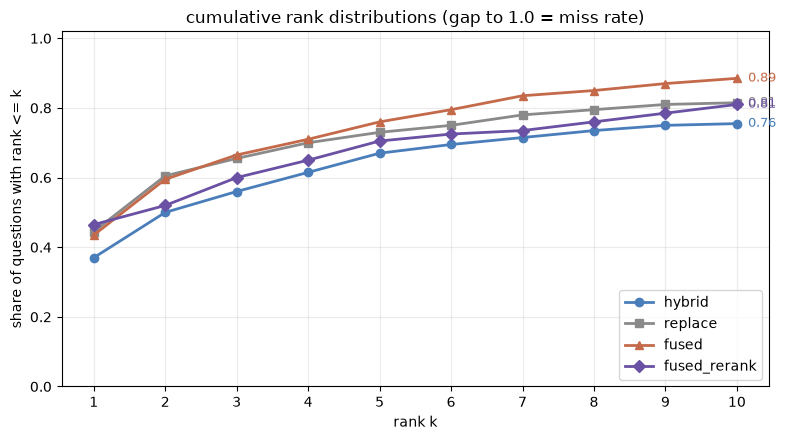

In [43]:
styles = {"hybrid": ("#4a7ebb", "o"), "replace": ("#8a8a8a", "s"),
          "fused": ("#c46a4a", "^"), "fused_rerank": ("#6a51a3", "D")}
ks = range(1, 11)

plt.figure(figsize=(8, 4.5))
for name, (color, marker) in styles.items():
    frame = rw_results[rw_results.config == name]
    curve = [(frame["rank"] <= k).mean() for k in ks]
    plt.plot(ks, curve, color=color, marker=marker, linewidth=2,
             markersize=6, label=name)
    plt.annotate(f"{curve[-1]:.2f}", (10, curve[-1]), xytext=(8, 0),
                 textcoords="offset points", color=color,
                 fontsize=9, va="center")
plt.xlabel("rank k")
plt.ylabel("share of questions with rank <= k")
plt.title("cumulative rank distributions (gap to 1.0 = miss rate)")
plt.xticks(list(ks))
plt.ylim(0, 1.02)
plt.grid(alpha=0.25)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Fused wins, by the largest margin of any change in the project**: hit rate 0.755 → 0.885 and hard subset 0.68 → 0.86, with the easy set essentially intact (0.98 → 0.96). Against the baseline it rescues 28 questions and breaks 2. The cost is one extra cheap LLM call, about 0.7 seconds per question.

**Replace** confirms the predicted risk: strong on the hard set (0.79), but it breaks 22 questions the baseline already answered — the translation sometimes drops the exact words that made a question easy.

**Fused + rerank is a negative result worth keeping.** It lands below fused alone (0.810 hit rate, hard 0.76) even though both ingredients help individually. The mechanism: the cross-encoder scores every candidate against the ORIGINAL question, never sees the translation, so it systematically demotes the notes the rewrite rescued — the second stage undoes the first because they do not share vocabulary. A v2 where the cross-encoder reads the rewritten query is left as future work.

The decision follows the numbers: fused is the new default retrieval mode in the application (`app.py` wires `RewriteFusedSearch` in front of the chain), reranking remains the quality mode over plain hybrid, and the plain modes stay available in `VaultSearcher`.

# Conclusion

Among the three plain search methods, hybrid performs best on both metrics and both difficulty levels, and it is the base every improvement below builds on. The easy subset is essentially saturated, reaching a 0.98 hit rate. The main room for improvement is therefore in the hard, adversarial subset, where roughly one question in three still fails to retrieve the expected note within the top 10.

The error analysis shows that these failures are not concentrated in a single problematic note. Most are near misses between thematically similar notes, together with a smaller tail of hard questions whose vocabulary differs strongly from that of the target note.

The cross-encoder reranker addresses the first group by improving the ordering of already retrieved candidates. It produces the largest pure ordering gain in the project, raising MRR from 0.491 to 0.543 and rank-1 hits from 74 to 91. The cost is about 4 seconds per query on CPU, so reranking is kept as the quality-oriented mode rather than the default.

The second failure mode cannot be fixed by reranking, because the correct note never enters the candidate set. Query rewriting addresses it before retrieval: an LLM translates the question into the vault's vocabulary, and hybrid search runs with both versions, merged with reciprocal rank fusion. Measured over the same 200 questions, this raises the hit rate from 0.755 to 0.885 and the hard subset from 0.68 to 0.86, rescuing 28 questions while breaking 2, for one extra LLM call of about 0.7 seconds. It is the largest improvement in the project, and it is now the default retrieval mode in the application. Stacking the reranker on top of the fused candidates was also measured and performs worse than fused alone (0.810 hit rate): the cross-encoder scores each candidate against the original question, never sees the translation, and demotes exactly the notes the rewrite rescued. Stages of a retrieval pipeline must share vocabulary.

Two embedding models were also compared during development: MiniLM and `bge-small`, with and without the query instruction prefix. Their performance on this vault was effectively tied, so the lighter MiniLM model was retained. The full comparison is documented in the exploration notebooks.
